In [2]:
# Get ELENA
!git clone https://github.com/michelelucente/ELENA.git
%cd ELENA

# Install Python deps for notebooks + examples
# (names follow ELENA’s README; CosmoTransitions is on PyPI)
%pip install -q numpy scipy matplotlib cosmoTransitions NatPy la-forge


Cloning into 'ELENA'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 624 (delta 168), reused 142 (delta 89), pack-reused 393 (from 1)
Receiving objects: 100% (624/624), 30.17 MiB | 17.21 MiB/s, done.
Resolving deltas: 100% (426/426), done.
/content/ELENA/ELENA


In [3]:

%%writefile model_3d.py


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

# ── physical constants ────────────────────────────────────────────────────────
GAMMA_E = 0.5772156649015328      # Euler-Mascheroni constant
A_GK    = 1.2824271291006226      # Glaisher-Kinkelin constant


# ── numerical helpers ─────────────────────────────────────────────────────────
def _pos32(x):
    """(max(x, 0))^{3/2}  used in the 3D one-loop M^{3/2} sum."""
    return np.power(np.maximum(x, 0.0), 1.5)


def _abs_sqrt(x):
    return np.sqrt(np.abs(np.asarray(x, dtype=float)))


def _safe_log(x, floor=1e-300):
    return np.log(np.maximum(np.abs(x), floor))


# ── 4D RGE  (paper App. B, Eq. B1) ───────────────────────────────────────────
def run_4d_params(g2_0, lam_0, m2_0, mu0, mu_target):
    """
    Evolve (g2, lam, m2) from mu0 to mu_target with one-loop beta functions
    (paper Eq. B1):

        beta_{g2}  =  g2^2 / (24 pi^2)
        beta_lam   = (10 lam^2 - 6 lam g2 + 3 g2^2) / (8 pi^2)
        beta_{m2}  =  m2 (4 lam - 3 g2) / (8 pi^2)
    """
    if abs(mu_target - mu0) / max(mu0, 1e-30) < 1e-12:
        return g2_0, lam_0, m2_0

    def rhs(t, y):
        g2, lam, m2 = y
        return [g2**2 / (24.0*np.pi**2),
                (10.0*lam**2 - 6.0*lam*g2 + 3.0*g2**2) / (8.0*np.pi**2),
                m2*(4.0*lam - 3.0*g2) / (8.0*np.pi**2)]

    t1  = np.log(mu_target / mu0)
    sol = solve_ivp(rhs, (0.0, t1), [g2_0, lam_0, m2_0],
                    method='RK45', rtol=1e-9, atol=1e-11,
                    max_step=max(abs(t1)/100.0, 1e-4))
    if not sol.success:
        raise RuntimeError(f"4D RGE failed: {sol.message}")
    return tuple(float(v) for v in sol.y[:, -1])


# ── matching logarithm  (paper Eq. A15) ──────────────────────────────────────
def _Lb(mu_match, T):
    """L_b = log( mu^2 exp(2 gamma_E) / (16 pi^2 T^2) )    [paper Eq. A15]"""
    return np.log(mu_match**2 * np.exp(2.0*GAMMA_E) / (16.0*np.pi**2*T**2))


# ── c_+  and  c_3  (paper text below Eq. A17) ────────────────────────────────
def _c_plus(Lb):
    """c_+ = (1/2)(gamma_E - L_b) - 6 ln(A_GK)    [paper below Eq. A17]"""
    return 0.5*(GAMMA_E - Lb) - 6.0*np.log(A_GK)


def _c3(Lb, mu3, mu_match):
    """
    c_3 = c_+ - log(mu3 / mu_match)    [paper Eq. A17]

    mu_match is the 4D->3D matching scale (= mu inside L_b).
    mu3      is the 3D soft renormalisation scale.
    """
    return _c_plus(Lb) - np.log(mu3 / mu_match)


# =============================================================================
# LO MATCHING  (paper Eqs. A19, A23, A24-LO)
# =============================================================================
def match_LO(g2_4d, lam_4d, m2_4d, T, mu_match=None):
    """
    Leading-order 4D -> 3D parameter matching.

    Paper-native sign convention: m3D2 > 0 in the broken phase.

    Scalar mass  (Eq. A19):  m3D2 = m2 - T^2 (3g2 + 4lam) / 12
    Debye mass   (Eq. A19):  muD2 = g2 T^2 / 3
    g3D2         (Eq. A23):  g3D2 = g2 T
    lamAPhi      (Eq. A23):  lamAPhi = 2 g2 T
    lam3D        (Eq. A24, LO-potential branch):
                              lam3D = T [g2^2 (2-3Lb) + 2lam(8pi^2 - 5Lb lam)] / (16 pi^2)
    """
    if mu_match is None:
        mu_match = 2.0*np.pi*T
    g2, lam, m2 = g2_4d, lam_4d, m2_4d
    Lb  = _Lb(mu_match, T)
    pi2 = np.pi**2

    g3D2    = g2 * T                                                    # Eq. A23
    lamAPhi = 2.0*g2*T                                                  # Eq. A23
    lam3D   = T*(g2**2*(2.0-3.0*Lb)
                 + 2.0*lam*(8.0*pi2-5.0*Lb*lam)) / (16.0*pi2)         # Eq. A24-LO
    m3D2    = m2 - T**2*(3.0*g2+4.0*lam)/12.0                         # Eq. A19
    muD2    = g2*T**2/3.0                                               # Eq. A19

    return dict(g3D2=g3D2, lam3D=lam3D, lamAPhi=lamAPhi,
                m3D2=m3D2, muD2=muD2)


# =============================================================================
# NLO MATCHING  (paper Eqs. A14, A17, A18, A20-A22)
# =============================================================================
def match_NLO(g2_4d, lam_4d, m2_4d, T, mu_match, mu3):
    """
    NLO 4D -> 3D matching.  mu3 must be supplied to evaluate c_3 in Eq. A17.

    Couplings  (Eqs. A20-A22):
        g3D2    = g2 T - g2^2 Lb T / (48 pi^2)
        lam3D   = lam T + T/(16pi^2) [g2^2(2-3Lb) + 6 g2 lam Lb - 10 lam^2 Lb]
        lamA    = g2^2 T / pi^2    [Eq. A14, stored but not used in V]
        lamAPhi = 2g2T + g2T/(24pi^2) [24lam - g2(Lb-4)]

    Scalar mass  (Eq. A17, in 4D couplings):
        m3D2 = m2 - T^2(3g2+4lam)/12
               + Lb(3g2-4lam)m2 / (16pi^2)
               + Lb(13g2^2 - 24g2 lam + 40 lam^2) T^2 / (192 pi^2)
               + c3(3g2^2 - 4g2 lam + 4 lam^2) T^2 / (8 pi^2)
               + (g2^2 - 3 g2 lam) T^2 / (72 pi^2)
        with c3 = c_+ - log(mu3/mu_match)

    Debye mass  (Eq. A18):
        muD2 = g2 T^2/3 + g2/(144pi^2) [12 lam T^2 + g2(7-Lb) T^2 - 36 m2]
    """
    g2, lam, m2 = g2_4d, lam_4d, m2_4d
    Lb  = _Lb(mu_match, T)
    pi2 = np.pi**2

    # one-loop couplings  (Eqs. A20-A22)
    g3D2    = g2*T - g2**2*Lb*T/(48.0*pi2)                             # Eq. A20
    lam3D   = (lam*T
               + T/(16.0*pi2)*(g2**2*(2.0-3.0*Lb)
                                + 6.0*g2*lam*Lb
                                - 10.0*lam**2*Lb))                     # Eq. A21
    lamA    = g2**2*T/pi2                                               # Eq. A14
    lamAPhi = (2.0*g2*T
               + g2*T/(24.0*pi2)*(24.0*lam - g2*(Lb-4.0)))            # Eq. A22

    # two-loop scalar mass with proper c3 split  (Eq. A17)
    c3   = _c3(Lb, mu3, mu_match)
    m3D2 = (m2
            - T**2*(3.0*g2+4.0*lam)/12.0
            + Lb*(3.0*g2-4.0*lam)*m2/(16.0*pi2)
            + Lb*(13.0*g2**2-24.0*g2*lam+40.0*lam**2)*T**2/(192.0*pi2)
            + c3*(3.0*g2**2-4.0*g2*lam+4.0*lam**2)*T**2/(8.0*pi2)
            + (g2**2-3.0*g2*lam)*T**2/(72.0*pi2))                     # Eq. A17

    # two-loop Debye mass  (Eq. A18)
    muD2 = (g2*T**2/3.0
            + g2/(144.0*pi2)*(12.0*lam*T**2
                               + g2*(7.0-Lb)*T**2
                               - 36.0*m2))                             # Eq. A18

    return dict(g3D2=g3D2, lam3D=lam3D, lamA=lamA, lamAPhi=lamAPhi,
                m3D2=m3D2, muD2=muD2)


# =============================================================================
# FIELD-DEPENDENT MASSES IN 3D  (paper Lagrangian Eq. A13)
# =============================================================================
def _masses_3d(phi_3d, m3D2, lam3D, g3D2, muD2, lamAPhi):
    """
    3D field-dependent masses for background phi_3d (3D-unit field,
    phi_3d = phi_4d / sqrt(T)).

    Paper-native sign: m3D2 > 0  gives broken direction in V_tree.

    Higgs (radial):    M_H2  = -m3D2 + 3 lam3D phi^2
    Goldstone:         M_G2  = -m3D2 +   lam3D phi^2
    Transverse A_i:    M_A2  =            g3D2  phi^2
    Temporal A_0:      M_A02 = muD2 + lamAPhi phi^2

    For M_A02: all quantities are already in 3D mass units.
    lamAPhi (from match_*) has dimension [mass], so lamAPhi * phi_3d^2
    has dimension [mass]^2 as required for a mass squared.
    No extra 1/T factor is needed.
    """
    phi2  = phi_3d**2
    mH2   = -m3D2 + 3.0*lam3D*phi2        # Higgs
    mG2   = -m3D2 +     lam3D*phi2        # Goldstone
    mA2   =              g3D2*phi2         # transverse gauge boson
    mA02  = muD2 + lamAPhi*phi2            # temporal A_0 (no /T)
    return mH2, mG2, mA2, mA02


# =============================================================================
# 3D TREE-LEVEL POTENTIAL  (paper Eq. A13, scalar sector)
# =============================================================================
def _V3D_tree(phi_3d, m3D2, lam3D):
    """
    V_tree = -(m3D2/2) phi^2 + (lam3D/4) phi^4     [paper Eq. A13]

    m3D2 > 0 gives the tachyonic (broken) direction.
    """
    phi2 = phi_3d**2
    return -0.5*m3D2*phi2 + 0.25*lam3D*phi2**2


# =============================================================================
# 3D ONE-LOOP POTENTIAL  (paper Section II / DR discussion)
# =============================================================================


def _V3D_1loop(phi_3d, m3D2, lam3D, g3D2, muD2, lamAPhi):
    mH2, mG2, mA2, mA02 = _masses_3d(
        phi_3d, m3D2, lam3D, g3D2, muD2, lamAPhi
    )

    return -(1.0 / (12.0 * np.pi)) * (
        _pos32(mH2)
        + _pos32(mG2)
        + 2.0 * _pos32(mA2)
        + _pos32(mA02)   # <-- keep this
    )

# =============================================================================
# 3D TWO-LOOP POTENTIAL  (DRalgo, paper Ref. [110])
# =============================================================================
def _V3D_2loop(phi_3d, m3D2, lam3D, g3D2, mu3):
    """
    Two-loop 3D EFT potential from the DRalgo framework [paper Ref. 110].

    Scalar+gauge sector masses (A_0 enters through mass matching, not
    explicit two-loop topology at this order):
        M_A2 = g3D2 phi^2
        M_G2 = -m3D2 + lam3D phi^2
        M_H2 = -m3D2 + 3 lam3D phi^2

    Shorthand:  sqX = sqrt(|M_X2|)
    3D loop logarithm:  lf(mu3, x) = 1/2 + log(mu3/x)

    Organized into Block A (gauge-Higgs), Block B (Goldstone-gauge),
    Block C (mirror of B), and cross/scalar terms.
    """
    phi_3d = np.asarray(phi_3d, dtype=float)
    phi2   = phi_3d**2
    pi, pi2 = np.pi, np.pi**2
    lam, g2 = lam3D, g3D2

    mA2 =  g2*phi2
    mG2 = -m3D2 + lam*phi2
    mH2 = -m3D2 + 3.0*lam*phi2

    sqA = _abs_sqrt(mA2)
    sqG = _abs_sqrt(mG2)
    sqH = _abs_sqrt(mH2)

    # guard phi = 0 (blocks divided by phi^2)
    phi2_safe = np.where(np.abs(phi_3d) < 1e-30, 1e-60, phi2)

    def lf(a, b):
        """3D loop log: 1/2 + log(mu3/sqrt(|mass^2|))"""
        return 0.5 + _safe_log(np.maximum(np.abs(a), 1e-300)
                               / np.maximum(np.abs(b), 1e-300))

    # -- Block A: gauge-Higgs sector ------------------------------------------
    nu_AH  = mA2 - mH2    # = g2 phi^2 - (-m3D2 + 3 lam phi^2)
    termA1 =  g2**2*phi2**2 / (8.0*pi2)
    termA2 = -g2*phi2*(m3D2 + 2.0*g2*phi2 - 3.0*lam*phi2) / (16.0*pi2)
    termA3 =  g2*phi2*sqA*sqH / (8.0*pi2)
    termA4 = -mH2**2*lf(mu3, sqH) / (16.0*pi2)
    termA5 =  nu_AH**2*lf(mu3, sqA+sqH) / (8.0*pi2)
    brA6   =  7.0*g2**2*phi2**2 + nu_AH**2 - 2.0*g2*phi2*mH2
    termA6 = -brA6*lf(mu3, 2.0*sqA+sqH) / (16.0*pi2)
    blockA = (termA1+termA2+termA3+termA4+termA5+termA6) / (4.0*phi2_safe)

    # -- Block B: Goldstone-gauge sector ---------------------------------------
    termB1 = -sqA*(mA2-2.0*lam*phi2)*sqG / (16.0*pi2)
    termB2 =  sqH*(mA2*sqG/(4.0*pi) - sqA*(mA2+2.0*lam*phi2)/(4.0*pi)) / (4.0*pi)
    termB3 =  lam**2*phi2**2*lf(mu3, sqG+sqH) / (4.0*pi2)
    # note: 2*msq_paper = 2*(-m3D2) appears in the bracket
    brB4   = (mA2**2 + 4.0*lam**2*phi2**2
              + 2.0*mA2*(2.0*m3D2 - 4.0*lam*phi2))
    termB4 = -brB4*lf(mu3, sqA+sqG+sqH) / (16.0*pi2)
    blockB = (termB1+termB2+termB3+termB4) / (4.0*phi2_safe)

    # -- Block C: mirror of B with G <-> H ------------------------------------
    termC1 = -sqA*(mA2+2.0*lam*phi2)*sqH / (16.0*pi2)
    termC2 =  sqG*(-sqA*(mA2-2.0*lam*phi2)/(4.0*pi)
                   + mA2*sqH/(4.0*pi)) / (4.0*pi)
    termC3 =  lam**2*phi2**2*lf(mu3, sqG+sqH) / (4.0*pi2)
    termC4 = -brB4*lf(mu3, sqA+sqG+sqH) / (16.0*pi2)
    blockC = (termC1+termC2+termC3+termC4) / (4.0*phi2_safe)

    # -- cross and pure-scalar terms -------------------------------------------
    cross_AG  =  g2*phi2*sqA*sqG / (16.0*pi2)
    cross_AH  =  g2*phi2*sqA*sqH / (16.0*pi2)
    scalar_G2 =  3.0*lam*mG2 / (64.0*pi2)
    scalar_H2 =  3.0*lam*mH2 / (64.0*pi2)
    log_H3    = -3.0*lam**2*phi2*lf(mu3, 3.0*sqH) / (16.0*pi2)
    log_GGH   = -lam**2*phi2*lf(mu3, 2.0*sqG+sqH) / (16.0*pi2)

    return (blockA + blockB + blockC
            + cross_AG + cross_AH
            + scalar_G2 + scalar_H2
            + log_H3 + log_GGH)


# =============================================================================
# FULL 3D POTENTIAL DISPATCHER
# =============================================================================
def V3D(phi_3d, params, loop_order=2, mu3=None):
    """
    Total 3D potential:   V = V_tree + V_1loop  [+ V_2loop]

    params must contain: m3D2, lam3D, g3D2, muD2, lamAPhi
    mu3 is required when loop_order >= 2.
    """
    phi_3d  = np.asarray(phi_3d, dtype=float)
    m3D2    = params['m3D2']
    lam3D   = params['lam3D']
    g3D2    = params['g3D2']
    muD2    = params['muD2']
    lamAPhi = params['lamAPhi']

    V = (_V3D_tree(phi_3d, m3D2, lam3D)
         + _V3D_1loop(phi_3d, m3D2, lam3D, g3D2, muD2, lamAPhi))

    if loop_order >= 2:
        if mu3 is None:
            raise ValueError("mu3 must be provided for loop_order >= 2.")
        V = V + _V3D_2loop(phi_3d, m3D2, lam3D, g3D2, mu3)

    return V


def V3D_to_4D(phi_4d, T, params, loop_order=2, mu3=None):
    """Map V_3D back to 4D:  V_4D(phi_4d, T) = T * V_3D(phi_4d / sqrt(T))."""
    phi_3d = np.asarray(phi_4d, dtype=float) / np.sqrt(T)
    return T * V3D(phi_3d, params, loop_order=loop_order, mu3=mu3)


# =============================================================================
# BASE CLASS
# =============================================================================
class DR3DSchemeBase:
    """
    Base class for all 3D DR schemes.

    mu_match_factor : mu_match = mu_match_factor * T   (default 2pi, paper Table I)
    mu3_factor      : mu3      = mu3_factor * T        (None -> mu3 = sqrt(g3D2))
    """
    def __init__(self, g2_0, lam_0, m2_0, mu0=1.0,
                 mu_match_factor=2.0*np.pi, mu3_factor=None):
        self.g2_0            = float(g2_0)
        self.lam_0           = float(lam_0)
        self.m2_0            = float(m2_0)
        self.mu0             = float(mu0)
        self.mu_match_factor = float(mu_match_factor)
        self.mu3_factor      = mu3_factor
        self._rge_cache      = {}

    def _run_to_match(self, T):
        mu_match = self.mu_match_factor * T
        key = round(mu_match, 14)
        if key not in self._rge_cache:
            self._rge_cache[key] = run_4d_params(
                self.g2_0, self.lam_0, self.m2_0, self.mu0, mu_match)
        return self._rge_cache[key], mu_match

    def mu3US(self, T, g3D2_val):
        """
        3D soft scale mu3.
        Default: mu3 = sqrt(g3D2) = g*sqrt(T)   (paper Table I: mu3 = g*T
        means the 3D coupling sqrt(g3D2) = g*sqrt(T)).
        """
        if self.mu3_factor is not None:
            return self.mu3_factor * T
        return np.sqrt(max(float(g3D2_val), 1e-30))

    def get_params(self, T):
        raise NotImplementedError

    def Vtot(self, phi_3d, T, subtract_origin=False):
        params = self.get_params(T)
        mu3    = self.mu3US(T, params['g3D2'])
        phi_3d = np.asarray(phi_3d, dtype=float)
        lo     = self.loop_order

        V = V3D(phi_3d, params, loop_order=lo, mu3=mu3)
        if subtract_origin:
            V -= V3D(np.zeros_like(phi_3d), params, loop_order=lo, mu3=mu3)
        return V

    def Vtot_4D(self, phi_4d, T, subtract_origin=False):
        phi_3d = np.asarray(phi_4d, dtype=float) / np.sqrt(T)
        return T * self.Vtot(phi_3d, T, subtract_origin=subtract_origin)

    def approxZeroTMin_4D(self, T, phi_hi_factor=10.0, n_points=400):
        params    = self.get_params(T)
        mu3       = self.mu3US(T, params['g3D2'])
        phi_hi_3d = phi_hi_factor*np.sqrt(T)
        phi_grid  = np.linspace(1e-6*np.sqrt(T), phi_hi_3d, n_points)
        lo        = self.loop_order

        V_grid = V3D(phi_grid, params, loop_order=lo, mu3=mu3)
        idx    = int(np.argmin(V_grid))
        lo_b   = phi_grid[max(idx-1, 0)]
        hi_b   = phi_grid[min(idx+1, n_points-1)]

        def obj(phi):
            return float(V3D(np.array([phi]), params, loop_order=lo, mu3=mu3)[0])

        res = minimize_scalar(obj, bounds=(lo_b, hi_b), method='bounded',
                              options={'xatol': 1e-10*phi_grid[idx]})
        return (float(res.x) if res.success else phi_grid[idx]) * np.sqrt(T)


# =============================================================================
# SCHEME 1: 3D 1-L (LO)
# =============================================================================
class DR3D_1L_LO(DR3DSchemeBase):
    """
    3D 1-L (LO) scheme  [paper Eqs. A19, A23, A24-LO].

    V = V_tree + V_1loop   (loop_order = 1)

    All parameters at strict leading order.
    Fixed-order expansion in 4D couplings g2, lam, m2.

    m3D2   = m2 - T^2(3g2+4lam)/12      [Eq. A19]
    muD2   = g2 T^2 / 3                 [Eq. A19]
    g3D2   = g2 T                       [Eq. A23]
    lamAPhi= 2 g2 T                     [Eq. A23]
    lam3D  = T[g2^2(2-3Lb)+2lam(8pi^2-5Lb lam)]/(16pi^2)   [Eq. A24-LO]
    """
    loop_order = 1

    def get_params(self, T):
        (g2, lam, m2), mu_match = self._run_to_match(T)
        return match_LO(g2, lam, m2, T, mu_match)


# =============================================================================
# SCHEME 2: 3D 1-L (NLO)
# =============================================================================
class DR3D_1L_NLO(DR3DSchemeBase):
    """
    3D 1-L (NLO) scheme  [paper Eqs. A17-A18, A20-A22].

    V = V_tree + V_1loop   (loop_order = 1)

    NLO masses (two-loop) and NLO couplings (one-loop),
    fed into a one-loop potential.  The mismatch amplifies mu3 sensitivity;
    this is the least stable scheme (paper Fig. 2, Section II).
    """
    loop_order = 1

    def get_params(self, T):
        (g2, lam, m2), mu_match = self._run_to_match(T)
        mu3 = self.mu3US(T, g2*T)    # LO estimate for c3 evaluation
        return match_NLO(g2, lam, m2, T, mu_match, mu3)

    def Vtot(self, phi_3d, T, subtract_origin=False):
        # loop_order=1 does not use mu3 in V3D, so pass None
        params = self.get_params(T)
        phi_3d = np.asarray(phi_3d, dtype=float)

        V = V3D(phi_3d, params, loop_order=1, mu3=None)
        if subtract_origin:
            V -= V3D(np.zeros_like(phi_3d), params, loop_order=1, mu3=None)
        return V


# =============================================================================
# SCHEME 3: 3D 2-L (NLO)  -- BENCHMARK
# =============================================================================
class DR3D_2L_NLO(DR3DSchemeBase):
    """
    3D 2-L (NLO) scheme  [paper's benchmark].

    V = V_tree + V_1loop + V_2loop   (loop_order = 2)

    NLO masses, NLO couplings, two-loop potential.
    The two-loop V provides compensating logarithms that cancel
    the mu3 sensitivity introduced by the NLO mass, giving the
    smallest residual scale dependence (paper Fig. 2).
    """
    loop_order = 2

    def get_params(self, T):
        (g2, lam, m2), mu_match = self._run_to_match(T)
        mu3 = self.mu3US(T, g2*T)   # LO estimate for c3 evaluation
        return match_NLO(g2, lam, m2, T, mu_match, mu3)


# =============================================================================
# SCHEME 4: 3D 2-L (Mixed)
# =============================================================================
class DR3D_2L_Mixed(DR3DSchemeBase):
    """
    3D 2-L (Mixed) scheme  [paper Section II].

    V = V_tree(NLO mass, LO-branch lam) + V_1loop(LO) + V_2loop(LO)

    Tree-level part:
        m3D2        = NLO two-loop   [Eq. A17]
        lam3D_tree  = LO-branch      [Eq. A24-LO, has Lb logs]

    Loop parts (V_1loop, V_2loop) use strict LO couplings:
        g3D2    = g2 T              [Eq. A23]
        lam3D   = lam T             [strict LO]
        lamAPhi = 2 g2 T            [Eq. A23]
        muD2    = g2 T^2/3          [Eq. A19]

    Fixed-order expansion like 3D 1-L (LO), but with the two-loop
    potential included.
    """
    loop_order = 2

    def get_params(self, T):
        (g2, lam, m2), mu_match = self._run_to_match(T)
        Lb  = _Lb(mu_match, T)
        pi2 = np.pi**2

        # strict LO couplings for loop parts
        g3D2_loop    = g2*T                          # Eq. A23
        lamAPhi_loop = 2.0*g2*T                      # Eq. A23
        lam3D_loop   = lam*T                         # strict LO
        muD2_loop    = g2*T**2/3.0                   # Eq. A19

        # LO-branch quartic with Lb logs for tree-level  (Eq. A24-LO)
        lam3D_tree = T*(g2**2*(2.0-3.0*Lb)
                        + 2.0*lam*(8.0*pi2-5.0*Lb*lam)) / (16.0*pi2)

        # NLO two-loop mass with proper c3 split  (Eq. A17)
        mu3  = self.mu3US(T, g3D2_loop)
        c3   = _c3(Lb, mu3, mu_match)
        m3D2 = (m2
                - T**2*(3.0*g2+4.0*lam)/12.0
                + Lb*(3.0*g2-4.0*lam)*m2/(16.0*pi2)
                + Lb*(13.0*g2**2-24.0*g2*lam+40.0*lam**2)*T**2/(192.0*pi2)
                + c3*(3.0*g2**2-4.0*g2*lam+4.0*lam**2)*T**2/(8.0*pi2)
                + (g2**2-3.0*g2*lam)*T**2/(72.0*pi2))              # Eq. A17

        return dict(
            m3D2       = m3D2,
            lam3D_tree = lam3D_tree,   # tree-level quartic
            g3D2       = g3D2_loop,
            lam3D      = lam3D_loop,   # loop-part quartic
            lamAPhi    = lamAPhi_loop,
            muD2       = muD2_loop,
        )

    def Vtot(self, phi_3d, T, subtract_origin=False):
        params = self.get_params(T)
        mu3    = self.mu3US(T, params['g3D2'])
        phi_3d = np.asarray(phi_3d, dtype=float)

        m3D2       = params['m3D2']
        lam3D_tree = params['lam3D_tree']
        lam3D_loop = params['lam3D']
        g3D2       = params['g3D2']
        muD2       = params['muD2']
        lamAPhi    = params['lamAPhi']

        def _V(phi):
            return (_V3D_tree(phi, m3D2, lam3D_tree)            # NLO mass, LO-branch lam
                    + _V3D_1loop(phi, m3D2, lam3D_loop,         # strict LO couplings
                                 g3D2, muD2, lamAPhi)
                    + _V3D_2loop(phi, m3D2, lam3D_loop,         # strict LO couplings
                                 g3D2, mu3))

        V = _V(phi_3d)
        if subtract_origin:
            V -= _V(np.zeros_like(phi_3d))
        return V


# =============================================================================
# CONVENIENCE FACTORY
# =============================================================================
SCHEME_MAP = {
    '3D 1-L (LO)'    : DR3D_1L_LO,
    '3D 1-L (NLO)'   : DR3D_1L_NLO,
    '3D 2-L (NLO)'   : DR3D_2L_NLO,
    '3D 2-L (Mixed)' : DR3D_2L_Mixed,
}


def make_scheme(name, g2_0, lam_0=0.0, m2_0=0.0, mu0=1.0,
                mu_match_factor=2.0*np.pi, mu3_factor=None):
    """
    Instantiate a DR scheme by name.

    Parameters
    ----------
    name               : one of SCHEME_MAP keys
    g2_0, lam_0, m2_0 : input 4D parameters at mu0
    mu0                : reference scale [GeV]
    mu_match_factor    : mu_match = mu_match_factor * T  (default 2pi, Table I)
    mu3_factor         : mu3      = mu3_factor * T       (None -> mu3 = sqrt(g3D2))
    """
    if name not in SCHEME_MAP:
        raise ValueError(f"Unknown scheme '{name}'. "
                         f"Choose from: {list(SCHEME_MAP.keys())}")
    return SCHEME_MAP[name](g2_0=g2_0, lam_0=lam_0, m2_0=m2_0, mu0=mu0,
                            mu_match_factor=mu_match_factor,
                            mu3_factor=mu3_factor)

Writing model_3d.py


In [4]:
import sys
import os
from pathlib import Path
import numpy as np
import time

# Get the directory of the current script
script_dir = Path(os.getcwd()).resolve()

# Add the src directory to the Python path
sys.path.append(str(Path(script_dir / '../src').resolve()))

figure_dir = '../data/processed/plots/manual/'
if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)



In [5]:
# Add ELENA/src to the Python path for imports (as suggested by the repo)
import sys, os
sys.path.append(os.path.abspath('src'))

In [16]:
import numpy as np
import temperatures as temp

def find_extrema_fast(
    V,
    dV_unused,
    T,
    Phimax=150,
    step=1,
    *,
    max_expand=2,
    Phimax_cap=1000,
    min_phi_cut=1e-6,
):
    T = float(T)
    if T <= 0.0:
        return [], [], []

    Phimax = float(Phimax)
    step   = float(step)

    # mimic ELENA behaviour: exclude phi=0
    phi = np.arange(step, Phimax + step, step, dtype=float)
    v = np.asarray(V(phi.reshape(-1, 1), T), dtype=float).reshape(-1)

    expand_counter = 0
    argmaxV = np.argmax(v)

    # --------------------------------------------------
    # Controlled expansion ONLY if maximum is at boundary
    # --------------------------------------------------
    while (argmaxV + 1) != len(v):
        if np.isnan(v[argmaxV]):
            return [], [], []

        expand_counter += 1
        if expand_counter > max_expand or Phimax >= Phimax_cap:
            break

        Phimax *= 2.0
        Phimax = min(Phimax, Phimax_cap)

        phi = np.arange(step, Phimax + step, step, dtype=float)
        v = np.asarray(V(phi.reshape(-1, 1), T), dtype=float).reshape(-1)
        argmaxV = np.argmax(v)

    # sanity check
    if len(v) < 5 or not np.all(np.isfinite(v)):
        return [], [], []

    # --------------------------------------------------
    # Derivative from uniform grid
    # --------------------------------------------------
    dv = np.gradient(v, phi)
    signs = np.sign(dv).astype(int)

    sign_changes = np.diff(signs)
    idxs = np.nonzero(np.abs(sign_changes) == 2)[0]

    loc, val, kind = [], [], []

    for idx in idxs:
        this_kind = "max" if sign_changes[idx] < 0 else "min"

        # linear dv=0 interpolation
        phi_pair = phi[idx:idx+2]
        dv_pair = dv[idx:idx+2]
        v_pair  = v[idx:idx+2]

        if this_kind == "max":
            xz = np.interp(0.0, dv_pair[::-1], phi_pair[::-1])
        else:
            xz = np.interp(0.0, dv_pair, phi_pair)

        if xz < min_phi_cut:
            continue
        vz = np.interp(xz, phi_pair, v_pair)

        kind.append(this_kind)
        loc.append(float(xz))
        val.append(float(vz))

    if not kind:
        return [], [], []

    # --------------------------------------------------
    # sort & truncate like ELENA, but HARD LIMIT LENGTH
    # --------------------------------------------------
    order = np.argsort(loc)
    kind = list(np.array(kind)[order])
    loc  = list(np.array(loc)[order])
    val  = list(np.array(val)[order])


    MAX_KEEP = 4
    kind = kind[:MAX_KEEP]
    loc  = loc[:MAX_KEEP]
    val  = val[:MAX_KEEP]

    # truncate past global minimum (ELENA logic)
    gmin = int(np.argmin(val))
    kind = kind[:gmin+1]
    loc  = loc[:gmin+1]
    val  = val[:gmin+1]

    return kind, loc, val


# === PATCH INTO ELENA ===
temp.find_extrema = find_extrema_fast


In [17]:
import numpy as np
import importlib
import model_3d

importlib.reload(model_3d)

from temperatures import find_T_min, find_T_max, refine_Tmin
from model_3d import make_scheme


# ============================================================
# Choose ONE scheme
# ============================================================
scheme = "3D-1L-NLO"
# "3D-1L-LO"
# "3D-1L-NLO"
# "3D-2L-NLO"
# "3D-2L-MIXED"


# ============================================================
# Model parameters
# ============================================================
g0 = 0.6
g2_0 = g0**2

lam0 = 0.0
m20 = 0.0
mu0 = 1.0

units = "GeV"


# ============================================================
# Numerical scan scales
# ============================================================
tmax = 1.2
T_precision = 1e-2

Phimax = 15
step_phi = 0.05

T_EPS = 1e-6


# ============================================================
# Scheme name map
# ============================================================
SCHEME_NAME_MAP = {
    "3D-1L-LO": "3D 1-L (LO)",
    "3D-1L-NLO": "3D 1-L (NLO)",
    "3D-2L-NLO": "3D 2-L (NLO)",
    "3D-2L-MIXED": "3D 2-L (Mixed)",
}

if scheme not in SCHEME_NAME_MAP:
    raise ValueError(f"Unknown scheme: {scheme}")


# ============================================================
# Build 3D DR model
# ============================================================
dp = make_scheme(
    SCHEME_NAME_MAP[scheme],
    g2_0=g2_0,
    lam_0=lam0,
    m2_0=m20,
    mu0=mu0,
    mu_match_factor=2.0 * np.pi,
    mu3_factor=None,
)


# ============================================================
# ELENA-style wrappers
#
# phi is the 4D-equivalent field phi4.
#
# Correct mapping:
#     phi3 = phi4 / sqrt(T)
#     V4_equiv(phi4, T) = T * V3(phi3, T)
# ============================================================
def V(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    out = np.asarray(
        dp.Vtot_4D(flat, T_use, subtract_origin=False),
        dtype=float,
    )

    if arr.ndim == 0:
        return float(out[0])

    return out.reshape(arr.shape)


def dV(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    flat = arr.reshape(-1)

    h_rel = 1e-4
    h_abs = 1e-6
    h = h_rel * np.maximum(np.abs(flat), 1.0) + h_abs

    out = np.array([
        (
            dp.Vtot_4D(x + dx, T_use, subtract_origin=False)
            - dp.Vtot_4D(x - dx, T_use, subtract_origin=False)
        ) / (2.0 * dx)
        for x, dx in zip(flat, h)
    ], dtype=float)

    if arr.ndim == 0:
        return float(out[0])

    return out.reshape(arr.shape)

# ============================================================
# ELENA-style temperature scan
# ============================================================
T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(
    V,
    dV,
    precision=T_precision,
    Phimax=Phimax,
    step_phi=step_phi,
    tmax=tmax,
)

if T_max is not None:
    T_min, vevs_min, false_min_tmin = find_T_min(
        V,
        dV,
        tmax=T_max,
        precision=T_precision,
        Phimax=Phimax,
        step_phi=step_phi,
        max_min_vals=max_min_vals,
    )
else:
    T_min, vevs_min, false_min_tmin = None, None, None


# ============================================================
# maxvev
# ============================================================
if T_max is not None and T_min is not None:
    maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
elif T_max is not None:
    maxvev = np.max(vevs_max)
elif T_min is not None:
    maxvev = np.max(vevs_min)
else:
    maxvev = None


# ============================================================
# Refine Tmin
# ============================================================
if T_min is not None and maxvev is not None:
    T_min = refine_Tmin(
        T_min,
        V,
        dV,
        maxvev,
        log_10_precision=6,
    )


# ============================================================
# Print results
# ============================================================
print(f"scheme = {scheme}")
print(f"g0 = {g0}")
print(f"g2_0 = {g2_0}")

print(f"T_max = {T_max:.6e} {units}" if T_max is not None else "T_max = None")
print(f"T_min = {T_min:.6e} {units}" if T_min is not None else "T_min = None")
print(f"maxvev = {maxvev:.6e}" if maxvev is not None else "maxvev = None")

if vevs_max is not None:
    print("vevs_max sample:", vevs_max[:5])

if vevs_min is not None:
    print("vevs_min sample:", vevs_min[:5])

scheme = 3D-1L-NLO
g0 = 0.6
g2_0 = 0.36
T_max = 6.492000e+00 GeV
T_min = 1.029274e-01 GeV
maxvev = 1.828032e+01
vevs_max sample: [18.28032377]
vevs_min sample: [8.79541383]


In [18]:
T_EPS=1e-6

def V(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    is_scalar = arr.ndim == 0

    flat = arr.reshape(-1)

    out = np.asarray(
        dp.Vtot_4D(flat, T_use, subtract_origin=False),
        dtype=float,
    ).reshape(-1)

    if is_scalar:
        return float(out[0])

    return out


def dV(phi, T, *args, **kwargs):
    T_use = max(float(T), T_EPS)

    arr = np.asarray(phi, dtype=float)
    is_scalar = arr.ndim == 0

    flat = arr.reshape(-1)

    h_rel = 1e-4
    h_abs = 1e-6
    h = h_rel * np.maximum(np.abs(flat), 1.0) + h_abs

    out = np.array([
        (
            dp.Vtot_4D(float(x + dx), T_use, subtract_origin=False)
            - dp.Vtot_4D(float(x - dx), T_use, subtract_origin=False)
        ) / (2.0 * dx)
        for x, dx in zip(flat, h)
    ], dtype=float).reshape(-1)

    if is_scalar:
        return float(out[0])

    return out

In [19]:
from espinosa import Vt_vec
import numpy as np

true_vev = {}
S3overT = {}
V_min_value = {}
phi0_min = {}
V_exit = {}
false_vev = {}

def action_over_T(T, c_step_phi=1e-3, precision=1e-3):
    T = float(T)

    # Fallback if maxvev was not determined cleanly
    vev0_guess = float(maxvev) if maxvev is not None and np.isfinite(maxvev) and maxvev > 0 else 1.0

    instance = Vt_vec(
        T,
        V,
        dV,
        step_phi=c_step_phi,
        precision=precision,
        vev0=vev0_guess,
        ratio_vev_step0=50,
    )

    if instance.barrier:
        true_vev[T] = float(instance.true_min)
        false_vev[T] = float(instance.phi_original_false_vev)
        S3overT[T] = float(instance.action_over_T)
        V_min_value[T] = float(instance.min_V)
        phi0_min[T] = float(instance.phi0_min)
        V_exit[T] = float(instance.V_exit)
        return float(instance.action_over_T)
    else:
        return None

In [20]:
import time
import numpy as np

n_points = 100

if T_min is None or T_max is None:
    raise RuntimeError("T_min or T_max is None. Run the temperature finder first and make sure a barrier exists.")

temperatures_scan = np.linspace(float(T_min), float(T_max), n_points)
action_vec = np.vectorize(action_over_T, otypes=[object])

start_time = time.time()
_ = action_vec(temperatures_scan)
end_time = time.time()

print(f"Elapsed time: {end_time - start_time:.2f} seconds")

# Keep only temperatures where the action was successfully computed
temperatures = np.array(
    [float(T) for T in temperatures_scan if float(T) in S3overT],
    dtype=float
)

if len(temperatures) == 0:
    raise RuntimeError("No valid S3/T points were computed. Try increasing the scan range or adjusting step_phi / vev0.")

/tmp/ipykernel_8551/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


Elapsed time: 21.46 seconds


In [21]:
description="3D-1L-NLO"

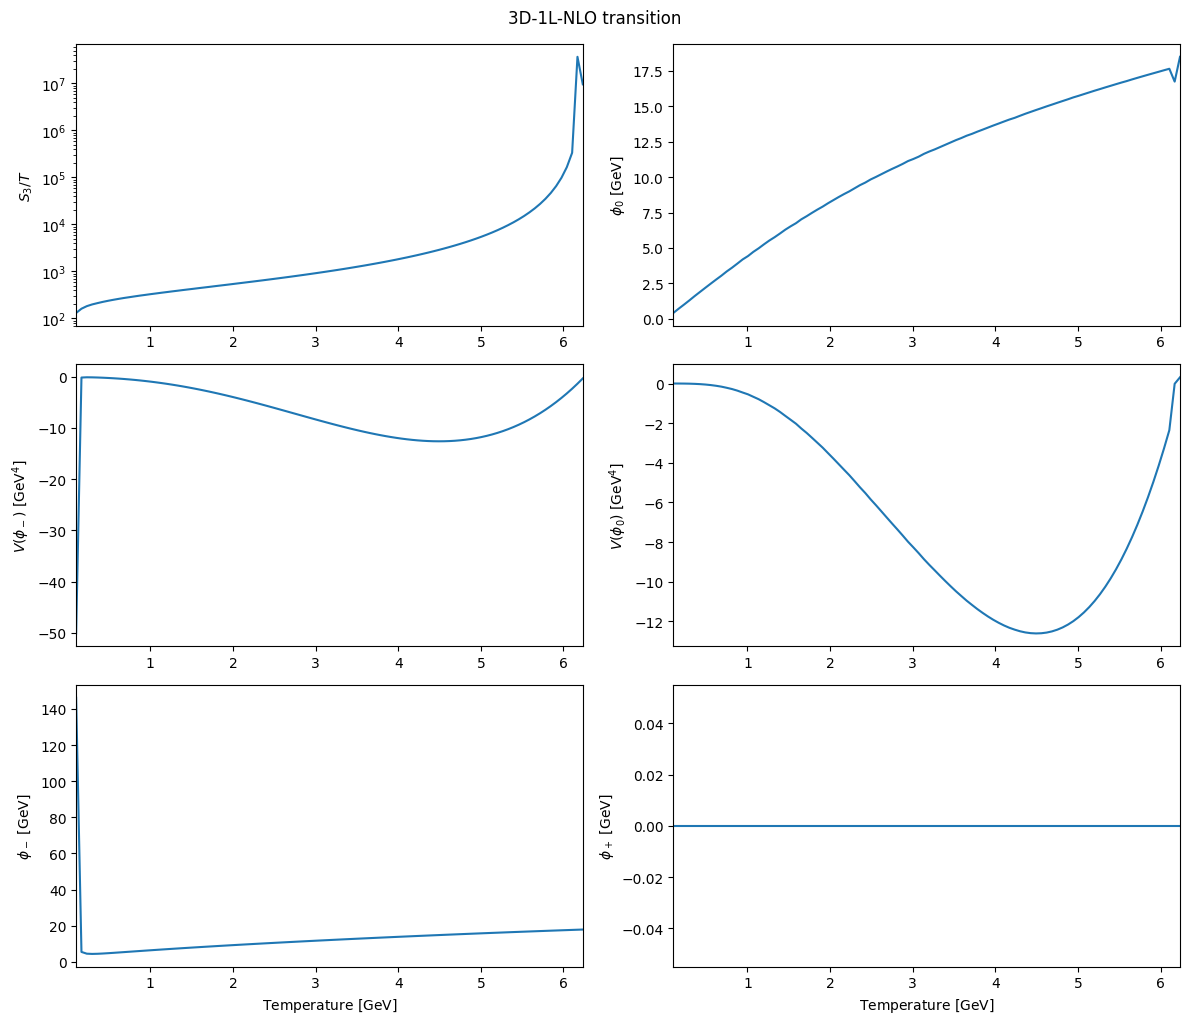

Minimum of the action at T = 1.03e-01 GeV


In [22]:
import matplotlib.pyplot as plt
import os

if len(temperatures) == 0:
    raise RuntimeError("No temperatures available for plotting.")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

S3_vals      = np.array([S3overT[T] for T in temperatures], dtype=float)
phi0_vals    = np.array([phi0_min[T] for T in temperatures], dtype=float)
Vmin_vals    = np.array([V_min_value[T] for T in temperatures], dtype=float)
Vexit_vals   = np.array([V_exit[T] for T in temperatures], dtype=float)
true_vals    = np.array([true_vev[T] for T in temperatures], dtype=float)
false_vals   = np.array([false_vev[T] for T in temperatures], dtype=float)

axes[0, 0].plot(temperatures, S3_vals)
axes[0, 0].set_ylabel(r'$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(temperatures, phi0_vals)
axes[0, 1].set_ylabel(f"$\\phi_0\\ \\mathrm{{[{units}]}}$")

axes[1, 0].plot(temperatures, Vmin_vals)
axes[1, 0].set_ylabel(f"$V(\\phi_-)\\ \\mathrm{{[{units}^4]}}$")

axes[1, 1].plot(temperatures, Vexit_vals)
axes[1, 1].set_ylabel(f"$V(\\phi_0)\\ \\mathrm{{[{units}^4]}}$")

axes[2, 0].plot(temperatures, true_vals)
axes[2, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 0].set_ylabel(f"$\\phi_-\\ \\mathrm{{[{units}]}}$")

axes[2, 1].plot(temperatures, false_vals)
axes[2, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 1].set_ylabel(f"$\\phi_+\\ \\mathrm{{[{units}]}}$")

for ax in axes.flatten():
    ax.set_xlim(np.min(temperatures), np.max(temperatures))

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.02)

# Save only if figure_dir exists
if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"action_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

T_at_min_action = temperatures[np.argmin(S3_vals)]
print(f"Minimum of the action at T = {T_at_min_action:.2e} {units}")

In [23]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

import temperatures as temp
from temperatures import N_bubblesH, R_sepH
from utils import interpolation_narrow


# ============================================================
# Helpers
# ============================================================
def scalar(x):
    return float(np.asarray(x, dtype=float).reshape(-1)[0])


def as_1d(x):
    return np.asarray(x, dtype=float).reshape(-1)


def is_increasing(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]

    if len(arr) < 2:
        return True

    return np.all(arr[:-1] <= arr[1:])


# ============================================================
# Safe 3D DR compute_logP_f
# Radiation-dominated ratio_V version:
# ratio_V = 3/T + d log(g_rho) / dT
# ============================================================
def compute_logP_f_3D_safe(
    V_min_value,
    S3overT,
    *,
    v_w=1.0,
    units="GeV",
    use_g_running=True,
    clip_exp=700.0,
):
    common_keys = sorted(set(V_min_value.keys()) & set(S3overT.keys()))
    Temps = np.array([float(T) for T in common_keys], dtype=float)

    if len(Temps) < 3:
        raise RuntimeError("Need at least 3 common temperatures in V_min_value and S3overT.")

    # Sort explicitly
    idx = np.argsort(Temps)
    Temps = Temps[idx]

    Vmin = np.array([scalar(V_min_value[float(T)]) for T in Temps], dtype=float)
    S3T = np.array([scalar(S3overT[float(T)]) for T in Temps], dtype=float)

    # Keep only finite points
    mask = np.isfinite(Temps) & np.isfinite(Vmin) & np.isfinite(S3T)
    Temps = Temps[mask]
    Vmin = Vmin[mask]
    S3T = S3T[mask]

    if len(Temps) < 3:
        raise RuntimeError("Need at least 3 finite common temperatures after filtering.")

    # --------------------------------------------------------
    # Hubble rate: vacuum + radiation
    # --------------------------------------------------------
    e_vac = -Vmin

    g = np.asarray(temp.g_rho(Temps / temp.convert_units[units]), dtype=float).reshape(-1)
    e_rad = (np.pi**2 / 30.0) * g * Temps**4

    H = np.sqrt(np.maximum(e_vac + e_rad, 0.0) / 3.0) / (
        temp.M_pl * temp.convert_units[units]
    )

    # --------------------------------------------------------
    # Nucleation rate
    # Gamma ~ T^4 (S3/2piT)^3/2 exp[-S3/T]
    # --------------------------------------------------------
    S3_clip = np.clip(S3T, 0.0, clip_exp)

    Gamma = (
        Temps**4
        * (np.maximum(S3T, 0.0) / (2.0 * np.pi))**1.5
        * np.exp(-S3_clip)
    )

    # --------------------------------------------------------
    # ratio_V
    # Stable radiation-dominated version
    # --------------------------------------------------------
    if use_g_running:
        ln_g = np.log(np.maximum(g, 1e-300))
        dln_g_dT = np.gradient(ln_g, Temps)
        ratio_V = 3.0 / Temps + dln_g_dT
    else:
        ratio_V = 3.0 / Temps

    # Force arrays to be clean 1D
    Temps = as_1d(Temps)
    ratio_V = as_1d(ratio_V)
    Gamma = as_1d(Gamma)
    H = as_1d(H)

    n = min(len(Temps), len(ratio_V), len(Gamma), len(H))
    Temps = Temps[:n]
    ratio_V = ratio_V[:n]
    Gamma = Gamma[:n]
    H = H[:n]

    logP_f = np.zeros_like(Temps, dtype=float)

    f_ext = ratio_V * Gamma / np.maximum(H, 1e-300)

    for i in range(len(Temps) - 1):
        Ts = as_1d(Temps[i:])
        r = as_1d(ratio_V[i:])
        Hs = as_1d(H[i:])
        fE = as_1d(f_ext[i:])

        nloc = min(len(Ts), len(r), len(Hs), len(fE))
        Ts = Ts[:nloc]
        r = r[:nloc]
        Hs = Hs[:nloc]
        fE = fE[:nloc]

        if nloc < 2:
            continue

        cum_r = cumulative_trapezoid(r, x=Ts, initial=0.0)

        f1 = r / np.maximum(Hs, 1e-300) * np.exp(cum_r / 3.0)
        cum_f1 = cumulative_trapezoid(f1, x=Ts, initial=0.0)

        f2 = fE * np.exp(-cum_r) * cum_f1**3
        cum_f2 = cumulative_trapezoid(f2, x=Ts, initial=0.0)

        logP_f[i] = -(4.0 / 243.0) * np.pi * v_w**3 * cum_f2[-1]

    return logP_f, Temps, ratio_V, Gamma, H


# ============================================================
# Milestone calculation
# Requires existing:
# dp, V_min_value, S3overT, action_vec,
# T_min, T_max, n_points, units
# ============================================================
is_physical = True

T_nuc = np.nan
T_perc = np.nan
T_completion = np.nan

counter = 0

while counter <= 1:

    # Refined second pass around milestone region
    if counter == 1:
        if np.isfinite(T_completion) and np.isfinite(T_nuc):
            T_lo = np.nanmax([T_min, 0.95 * T_completion])
            T_hi = np.nanmin([T_max, 1.05 * T_nuc])

            if np.isfinite(T_lo) and np.isfinite(T_hi) and T_hi > T_lo:
                temperatures_refined = np.linspace(T_lo, T_hi, n_points, endpoint=True)
                _ = action_vec(temperatures_refined)

    logP_f, Temps, ratio_V, Gamma, H = compute_logP_f_3D_safe(
        V_min_value,
        S3overT,
        v_w=1.0,
        units=units,
        use_g_running=True,
        clip_exp=700.0,
    )

    RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
    nH = N_bubblesH(Temps, Gamma, logP_f, H, ratio_V)

    Temps = as_1d(Temps)
    logP_f = as_1d(logP_f)
    ratio_V = as_1d(ratio_V)
    Gamma = as_1d(Gamma)
    H = as_1d(H)
    nH = as_1d(nH)

    print(f"\nPass {counter}")
    print(f"Temps range:   {Temps[0]:.6e} -> {Temps[-1]:.6e}   N={len(Temps)}")
    print(f"ratio_V range: {np.nanmin(ratio_V):.6e} -> {np.nanmax(ratio_V):.6e}")
    print(f"logP_f range:  {np.nanmin(logP_f):.6e} -> {np.nanmax(logP_f):.6e}")
    print(f"nH range:      {np.nanmin(nH):.6e} -> {np.nanmax(nH):.6e}")

    # --------------------------------------------------------
    # Nucleation: N_bubbles / Hubble volume = 1
    # --------------------------------------------------------
    mask_nH = np.isfinite(nH) & (nH > 0.0) & np.isfinite(Temps)

    if np.any(mask_nH):
        T_nuc = interpolation_narrow(np.log(nH[mask_nH]), Temps[mask_nH], 0.0)
    else:
        T_nuc = np.nan

    # --------------------------------------------------------
    # Percolation/completion from false-vacuum probability
    # --------------------------------------------------------
    mask_Pf = np.isfinite(logP_f) & np.isfinite(Temps)

    if np.any(mask_Pf):
        T_perc = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.71))
        T_completion = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.01))
    else:
        T_perc = np.nan
        T_completion = np.nan

    # --------------------------------------------------------
    # Completion sanity check
    # --------------------------------------------------------
    if np.isfinite(T_completion):
        idx_compl = int(np.argmin(np.abs(Temps - T_completion)))

        idx_lo = max(idx_compl - 1, 0)
        idx_hi = min(idx_compl + 2, len(Temps))

        test_completion = logP_f[idx_lo:idx_hi]
        test_completion = test_completion[np.isfinite(test_completion)]

        print("completion check:", counter, T_completion, test_completion)
        print("is increasing:", is_increasing(test_completion))

        if not is_increasing(test_completion):
            T_completion = np.nan
    else:
        print("completion check:", counter, T_completion, np.array([]))
        print("is increasing:", True)

    # --------------------------------------------------------
    # Physical-volume check on second pass
    # --------------------------------------------------------
    if counter == 1:
        d_dT_logP_f = np.gradient(logP_f, Temps)

        if np.isfinite(T_perc):
            log_at_T_perc = interpolation_narrow(Temps, d_dT_logP_f, T_perc)
            ratio_V_at_T_perc = interpolation_narrow(Temps, ratio_V, T_perc)

            if np.isfinite(log_at_T_perc) and np.isfinite(ratio_V_at_T_perc):
                if ratio_V_at_T_perc > log_at_T_perc:
                    is_physical = False
                    print(
                        "\n*** The physical volume at percolation is not decreasing. "
                        "The production of GW is questionable. ***"
                    )

        if np.isfinite(T_completion):
            log_at_T_completion = interpolation_narrow(Temps, d_dT_logP_f, T_completion)
            ratio_V_at_T_completion = interpolation_narrow(Temps, ratio_V, T_completion)

    counter += 1


# ============================================================
# Make sure milestone temperatures are included in action dicts
# ============================================================
milestones = [T_max, T_nuc, T_perc, T_completion, T_min]
milestones = [float(m) for m in milestones if m is not None and np.isfinite(m)]

if len(milestones) > 0:
    _ = action_vec(np.array(milestones, dtype=float))


# ============================================================
# Plotting mask around milestone window
# ============================================================
milestone_window = [T_completion, T_perc, T_nuc]
milestone_window = [m for m in milestone_window if np.isfinite(m)]

if len(milestone_window) > 0:
    t_mil_min = np.nanmin(milestone_window)
    t_mil_max = np.nanmax(milestone_window)

    idx_min = max(int(np.argmin(np.abs(Temps - t_mil_min))), 0)
    idx_max = min(int(np.argmin(np.abs(Temps - t_mil_max))), len(Temps) - 1)

    idx_min = idx_min if Temps[idx_min] <= t_mil_min else max(idx_min - 1, 0)
    idx_max = idx_max if Temps[idx_max] >= t_mil_max else min(idx_max + 1, len(Temps) - 1)

    mask = (Temps >= Temps[idx_min]) & (Temps <= Temps[idx_max])
else:
    mask = Temps >= 0


# ============================================================
# Final output
# ============================================================
print()
print(f"T_nuc        = {T_nuc:.6e} {units}" if np.isfinite(T_nuc) else "T_nuc        = nan")
print(f"T_perc       = {T_perc:.6e} {units}" if np.isfinite(T_perc) else "T_perc       = nan")
print(f"T_completion = {T_completion:.6e} {units}" if np.isfinite(T_completion) else "T_completion = nan")
print(f"is_physical  = {is_physical}")

/content/ELENA/src/temperatures.py:433: RuntimeWarning: divide by zero encountered in power
  return n**(-1/3) * H, n**(-1/3)



Pass 0
Temps range:   1.029274e-01 -> 6.233856e+00   N=96
ratio_V range: 4.837563e-01 -> 3.846533e+01
logP_f range:  -1.024974e+04 -> 0.000000e+00
nH range:      -0.000000e+00 -> 4.537441e+05
completion check: 0 0.16743444882406194 [-1.02497443e+04 -3.39132509e-05 -1.87154563e-12]
is increasing: True


/tmp/ipykernel_8551/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)



Pass 1
Temps range:   1.029274e-01 -> 6.233856e+00   N=196
ratio_V range: 4.837563e-01 -> 3.827527e+01
logP_f range:  -3.967696e+04 -> 0.000000e+00
nH range:      -0.000000e+00 -> 1.263023e+04
completion check: 1 0.1643340863909246 [-5.6579114  -4.54720158 -3.62886257]
is increasing: True

T_nuc        = 1.996773e-01 GeV
T_perc       = 1.713662e-01 GeV
T_completion = 1.643341e-01 GeV
is_physical  = True


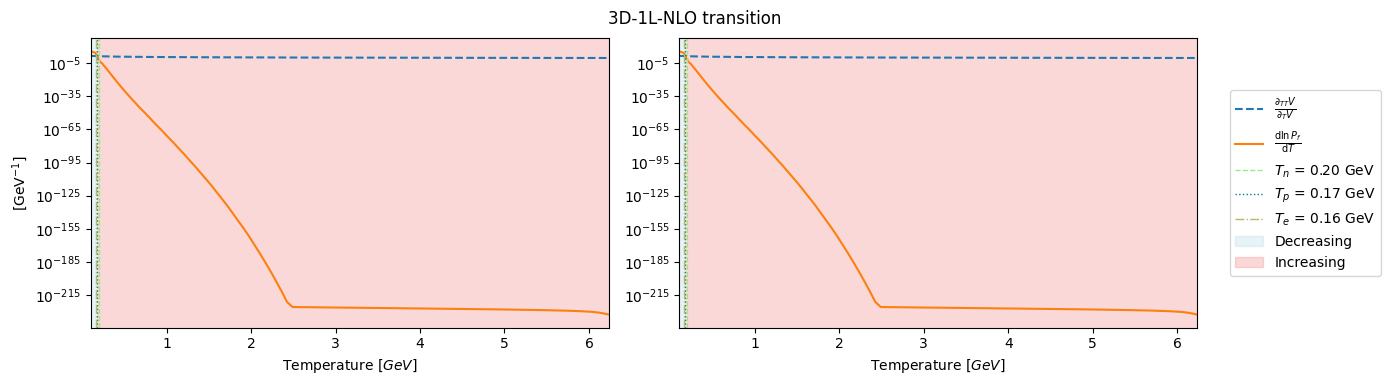

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Basic safety
Temps = np.asarray(Temps, dtype=float)
ratio_V = np.asarray(ratio_V, dtype=float)
d_dT_logP_f = np.asarray(d_dT_logP_f, dtype=float)
mask = np.ones_like(Temps, dtype=bool) # Initialize mask

if len(Temps) < 2:
    raise RuntimeError("Not enough temperature points to make the volume-evolution plot.")

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full-range plot
axes[0].plot(Temps, ratio_V, label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[0].plot(Temps, d_dT_logP_f, label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(fr"$\mathrm{{[{units}^{{-1}}]}}$")

# Zoomed plot
axes[1].plot(Temps[mask], ratio_V[mask], label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[1].plot(Temps[mask], d_dT_logP_f[mask], label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# Legend patches
decreasing_patch = mpatches.Patch(color='lightblue', alpha=0.3, label='Decreasing')
increasing_patch = mpatches.Patch(color='lightcoral', alpha=0.3, label='Increasing')

# Find intersections between d_dT_logP_f and ratio_V
intersections = []
diff = d_dT_logP_f - ratio_V

for i in range(len(Temps) - 1):
    y1, y2 = diff[i], diff[i + 1]
    x1, x2 = Temps[i], Temps[i + 1]

    if not (np.isfinite(y1) and np.isfinite(y2) and np.isfinite(x1) and np.isfinite(x2)):
        continue

    # exact hit
    if y1 == 0:
        intersections.append(x1)

    # crossing
    elif y1 * y2 < 0:
        denom = (y2 - y1)
        if denom != 0:
            x_cross = x1 - y1 * (x2 - x1) / denom
            if np.isfinite(x_cross):
                intersections.append(x_cross)

# Add precise crossing points to define colored intervals
all_points = np.sort(np.unique(np.concatenate([Temps, np.array(intersections, dtype=float)])))

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel(fr"$\mathrm{{Temperature}}\ [{units}]$")

    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}}$ = {T_completion:.2f} {units}')

    # Color intervals using midpoint test
    for i in range(len(all_points) - 1):
        x_left, x_right = all_points[i], all_points[i + 1]
        x_mid = 0.5 * (x_left + x_right)

        d_mid = np.interp(x_mid, Temps, d_dT_logP_f)
        r_mid = np.interp(x_mid, Temps, ratio_V)

        if np.isfinite(d_mid) and np.isfinite(r_mid):
            if d_mid >= r_mid:
                ax.axvspan(x_left, x_right, facecolor='lightblue', alpha=0.3)
            else:
                ax.axvspan(x_left, x_right, facecolor='lightcoral', alpha=0.3)

# Put the legend on the right panel
handles, labels = axes[1].get_legend_handles_labels()
handles.extend([decreasing_patch, increasing_patch])
labels.extend(['Decreasing', 'Increasing'])
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(f'{description} transition', y=0.95)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"volume_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\ '
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\ '
<>:56: SyntaxWarning: invalid escape sequence '\ '
<>:59: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\ '
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\ '
<>:56: SyntaxWarning: invalid escape sequence '\ '
<>:59: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_8551/4135002852.py:37: SyntaxWarning: invalid escape sequence '\m'
  axes[1, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
/tmp/ipykernel_8551/4135002852.py:37: SyntaxWarning: invalid escape sequence '\ '
  axes[1, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]

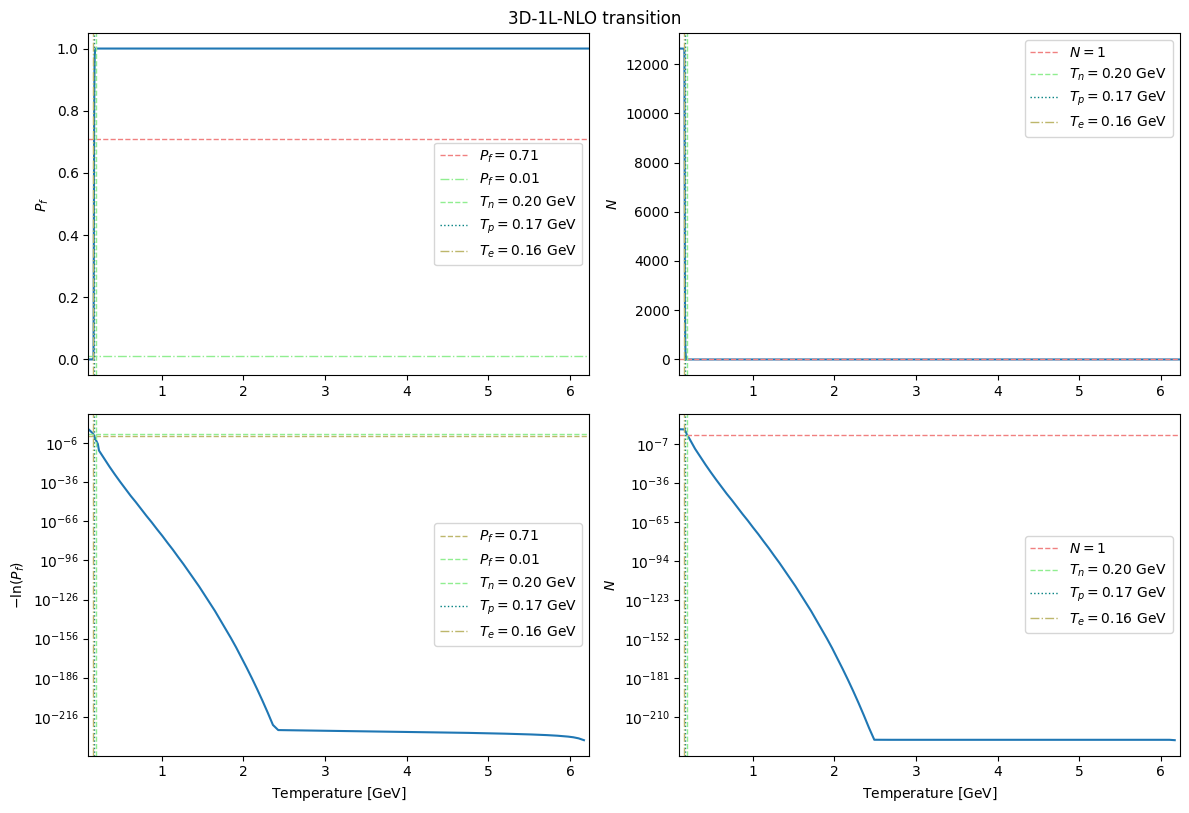

Average number of bubbles at T_min, N = 1.263e+04


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os

Temps = np.asarray(Temps, dtype=float)
logP_f = np.asarray(logP_f, dtype=float)
nH = np.asarray(nH, dtype=float)
mask_nH = np.isfinite(nH) # Fixed: Initialize mask_nH here

Pf = np.exp(logP_f)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Pf
axes[0, 0].plot(Temps, Pf)
axes[0, 0].set_ylabel(r'$P_f$')
axes[0, 0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[0, 0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=r'$P_f = 0.01$')
axes[0, 0].legend()

# Top-right: N
if np.any(mask_nH):
    axes[0, 1].plot(Temps[mask_nH], nH[mask_nH])
axes[0, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[0, 1].set_ylabel(r'$N$')
axes[0, 1].legend()

# Bottom-left: -ln(Pf)
minus_logPf = -logP_f
mask_log = np.isfinite(minus_logPf) & (minus_logPf > 0)

if np.any(mask_log):
    axes[1, 0].plot(Temps[mask_log], minus_logPf[mask_log])

axes[1, 0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[1, 0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=r'$P_f = 0.01$')
axes[1, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1, 0].set_ylabel(r'$-\ln(P_f)$')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Bottom-right: N in log scale
mask_nH_log = np.isfinite(nH) & (nH > 0)
if np.any(mask_nH_log):
    axes[1, 1].plot(Temps[mask_nH_log], nH[mask_nH_log])
axes[1, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[1, 1].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[1, 1].set_ylabel(r'$N$')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# Milestone lines
for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\ \mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\ \mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\ \mathrm{{{units}}}$')
    ax.set_xlim(Temps[0], Temps[-1])
    ax.legend()

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"evolution_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

if np.any(mask_nH):
    print(f"Average number of bubbles at T_min, N = {nH[mask_nH][0]:.3e}")
else:
    print("Average number of bubbles at T_min, N = nan")

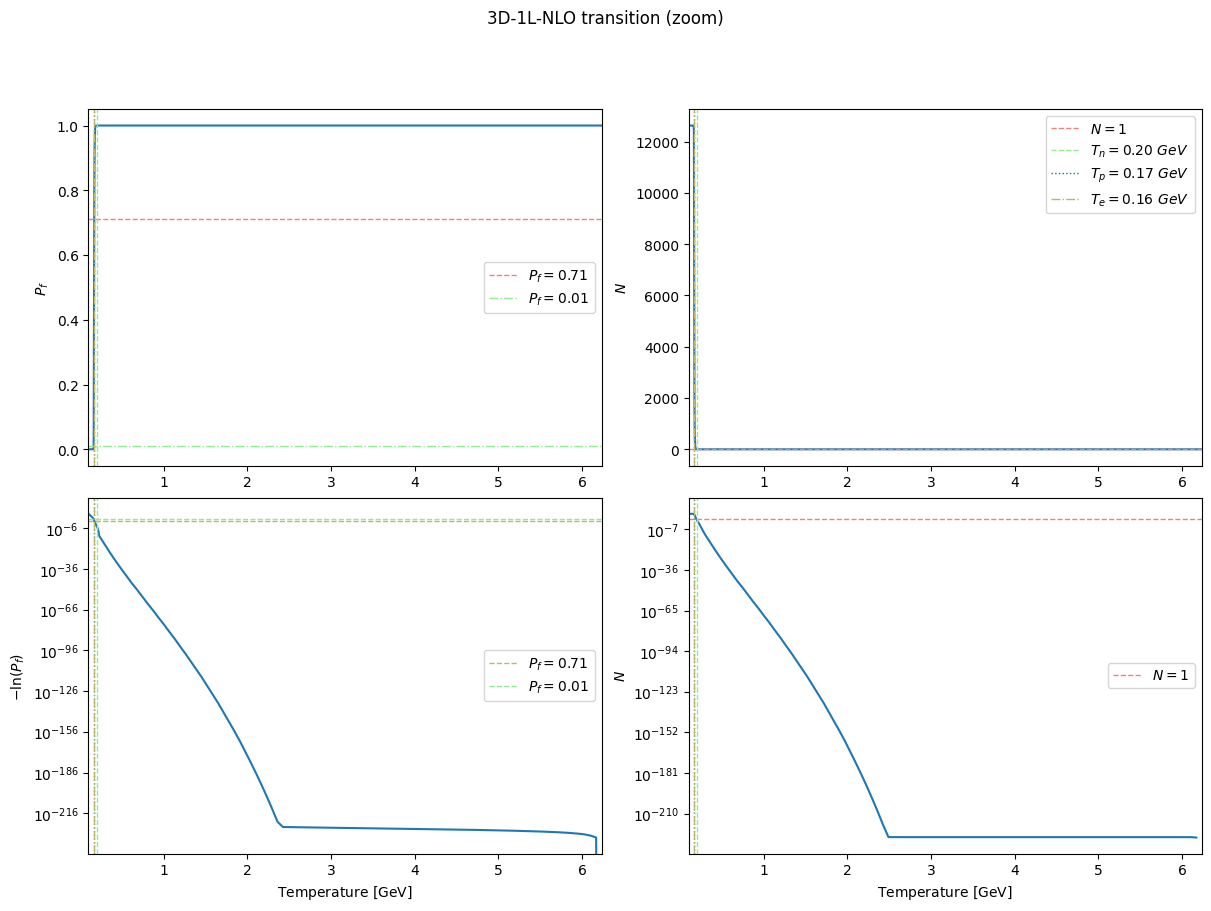

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

# assumes you already have:
# Temps, logP_f, nH, mask, T_nuc, T_perc, T_completion, units, description, figure_dir

os.makedirs(figure_dir, exist_ok=True)

# zoom arrays
Tz = Temps[mask]
logPz = logP_f[mask]
nHz = nH[mask]

# plotting-safe Pf
Pfz = np.exp(np.clip(logPz, -700.0, 0.0))

# for log-plot of N: keep only positive finite values
mask_nH_pos = np.isfinite(nHz) & (nHz > 0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Pf (linear)
axes[0,0].plot(Tz, Pfz)
axes[0,0].set_ylabel(r"$P_f$")
axes[0,0].axhline(0.71, color="lightcoral", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[0,0].axhline(0.01, color="lightgreen", linestyle="-.", linewidth=1, label=r"$P_f=0.01$")
axes[0,0].legend()

# N (linear)
axes[0,1].plot(Tz, nHz)
axes[0,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[0,1].set_ylabel(r"$N$")
axes[0,1].legend()

# -log Pf (log y)
axes[1,0].plot(Tz, -logPz)
axes[1,0].axhline(-np.log(0.71), color="darkkhaki", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[1,0].axhline(-np.log(0.01), color="lightgreen", linestyle="--", linewidth=1, label=r"$P_f=0.01$")
axes[1,0].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,0].set_ylabel(r"$-\ln(P_f)$")
axes[1,0].set_yscale("log")
axes[1,0].legend()

# N (log y) – use positive points only
axes[1,1].plot(Tz[mask_nH_pos], nHz[mask_nH_pos])
axes[1,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[1,1].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,1].set_ylabel(r"$N$")
axes[1,1].set_yscale("log")
axes[1,1].legend()

# milestone vertical lines (avoid duplicating legend spam)
for ax in axes.flatten():
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1)
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1)
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1)
    ax.set_xlim(Tz[0], Tz[-1])

# add one milestone legend (clean) in top-right panel
milestone_handles = [
    plt.Line2D([0],[0], color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n={T_nuc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p={T_perc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e={T_completion:.2f}\ {units}$"),
]
h0, l0 = axes[0,1].get_legend_handles_labels()
axes[0,1].legend(h0 + milestone_handles, l0 + [h.get_label() for h in milestone_handles], loc="best")

fig.suptitle(f"{description} transition (zoom)", y=1.12)
plt.savefig(os.path.join(figure_dir, f"evolution_{description}_zoom.pdf"), dpi=300, bbox_inches="tight")
plt.show()


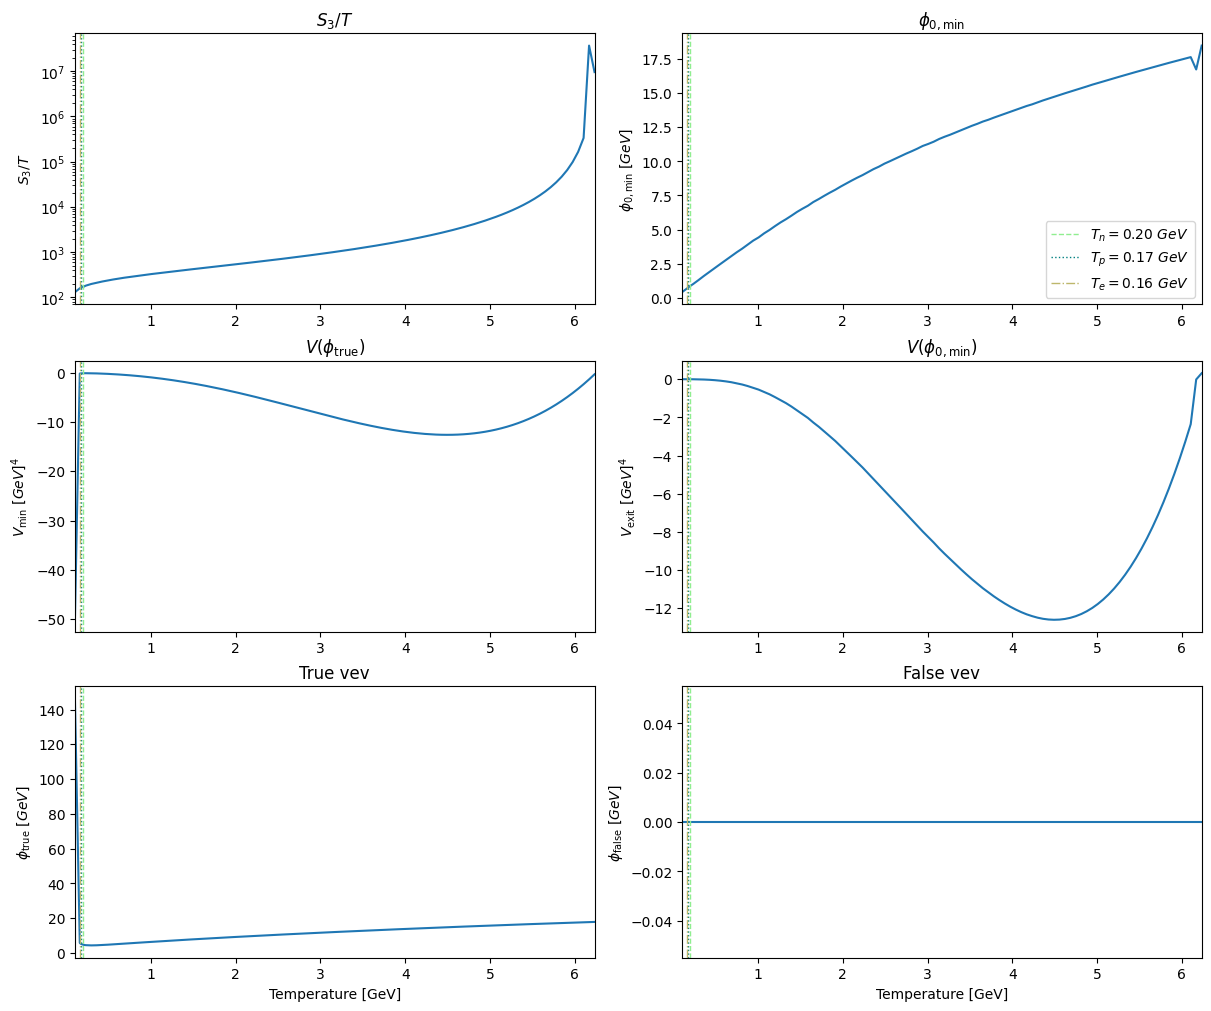

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# assumes you already have:
# Temps, mask, units, T_nuc, T_perc, T_completion
# dicts: S3overT, phi0_min, V_min_value, V_exit, true_vev, false_vev

Tz = np.asarray(Temps[mask], float)

def vec_from_dict(d, Tgrid):
    out = np.full_like(Tgrid, np.nan, dtype=float)
    for i, T in enumerate(Tgrid):
        # keys are floats; try exact then nearest fallback
        if T in d:
            out[i] = d[T]
        else:
            # nearest key fallback (safe for float rounding issues)
            ks = np.asarray(list(d.keys()), float)
            j = int(np.argmin(np.abs(ks - T)))
            out[i] = d[float(ks[j])]
    return out

S3z   = vec_from_dict(S3overT,    Tz)
phi0z = vec_from_dict(phi0_min,   Tz)
Vminz = vec_from_dict(V_min_value,Tz)
Vexz  = vec_from_dict(V_exit,     Tz)
phit  = vec_from_dict(true_vev,   Tz)
phif  = vec_from_dict(false_vev,  Tz)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

axes[0,0].plot(Tz, np.clip(S3z, 1e-300, None))
axes[0,0].set_title(r"$S_3/T$")
axes[0,0].set_ylabel(r"$S_3/T$")
axes[0,0].set_yscale("log")

axes[0,1].plot(Tz, phi0z)
axes[0,1].set_title(r"$\phi_{0,\mathrm{min}}$")
axes[0,1].set_ylabel(rf"$\phi_{{0,\mathrm{{min}}}}\ [{units}]$")

axes[1,0].plot(Tz, Vminz)
axes[1,0].set_title(r"$V(\phi_{\rm true})$")
axes[1,0].set_ylabel(rf"$V_{{\mathrm{{min}}}}\ [{units}]^4$")

axes[1,1].plot(Tz, Vexz)
axes[1,1].set_title(r"$V(\phi_{0,\mathrm{min}})$")
axes[1,1].set_ylabel(rf"$V_{{\mathrm{{exit}}}}\ [{units}]^4$")

axes[2,0].plot(Tz, phit)
axes[2,0].set_title("True vev")
axes[2,0].set_xlabel(rf"Temperature [{units}]")
axes[2,0].set_ylabel(rf"$\phi_{{\mathrm{{true}}}}\ [{units}]$")

axes[2,1].plot(Tz, phif)
axes[2,1].set_title("False vev")
axes[2,1].set_xlabel(rf"Temperature [{units}]")
axes[2,1].set_ylabel(rf"$\phi_{{\mathrm{{false}}}}\ [{units}]$")

# milestone handles (single clean legend style)
milestone_handles = [
    plt.Line2D([0],[0], color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n={T_nuc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p={T_perc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e={T_completion:.2f}\ {units}$"),
]

for ax in axes.flatten():
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1)
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1)
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1)
    ax.set_xlim(Tz[0], Tz[-1])

# put the milestone legend once (top-right panel)
axes[0,1].legend(handles=milestone_handles, loc="best")

plt.show()


In [28]:
import types
import numpy as np

def _safe_phi_value(phi):
    arr = np.asarray(phi, dtype=float).reshape(-1)
    return float(arr[0])

def dVdT_3d(self, phi, T, include_radiation=True, include_SM=True, units="GeV"):
    phi = _safe_phi_value(phi)
    T = float(T)

    h = max(1e-5, 1e-3 * abs(T))

    Tm = max(T - h, T_EPS)
    Tp = T + h

    Vm = float(self.Vtot_4D(phi, Tm, subtract_origin=False))
    Vp = float(self.Vtot_4D(phi, Tp, subtract_origin=False))

    return (Vp - Vm) / (Tp - Tm)


def d2VdT2_3d(self, phi, T, include_radiation=True, include_SM=True, units="GeV"):
    phi = _safe_phi_value(phi)
    T = float(T)

    h = max(1e-5, 1e-3 * abs(T))

    Tm = max(T - h, T_EPS)
    Tp = T + h

    Vm = float(self.Vtot_4D(phi, Tm, subtract_origin=False))
    V0 = float(self.Vtot_4D(phi, T,  subtract_origin=False))
    Vp = float(self.Vtot_4D(phi, Tp, subtract_origin=False))

    return (Vp - 2.0 * V0 + Vm) / (h**2)


dp.dVdT = types.MethodType(dVdT_3d, dp)
dp.d2VdT2 = types.MethodType(d2VdT2_3d, dp)

In [29]:
import numpy as np

def cs2_safe(T, m, true_vev, units="GeV", fallback=1.0/3.0):
    T = float(T)

    if T not in true_vev:
        keys = np.asarray(list(true_vev.keys()), dtype=float)
        T_key = float(keys[np.argmin(np.abs(keys - T))])
    else:
        T_key = T

    v_t = float(np.asarray(true_vev[T_key], dtype=float).reshape(-1)[0])

    dVdT_val = float(np.asarray(
        m.dVdT(v_t, T, include_radiation=True, include_SM=True, units=units)
    ).reshape(-1)[0])

    d2VdT2_val = float(np.asarray(
        m.d2VdT2(v_t, T, include_radiation=True, include_SM=True, units=units)
    ).reshape(-1)[0])

    denom = T * d2VdT2_val

    if not np.isfinite(dVdT_val) or not np.isfinite(d2VdT2_val):
        return fallback

    if abs(denom) < 1e-30:
        return fallback

    speed2 = dVdT_val / denom

    if not np.isfinite(speed2):
        return fallback

    if speed2 <= 0.0:
        return fallback

    return min(fallback, speed2)

In [31]:
import numpy as np

# ============================================================
# Helpers
# ============================================================
def scalar(x):
    return float(np.asarray(x, dtype=float).reshape(-1)[0])


def get_dict_value_nearest(d, T):
    T = float(T)

    if T in d:
        return d[T]

    keys = np.asarray(list(d.keys()), dtype=float)
    key = float(keys[np.argmin(np.abs(keys - T))])
    return d[key]


# ============================================================
# Safe cs2
# ============================================================
def cs2_safe(T, m, true_vev, units="GeV", fallback=1.0 / 3.0):
    T = float(T)

    v_t = scalar(get_dict_value_nearest(true_vev, T))

    dVdT_val = scalar(
        m.dVdT(
            v_t,
            T,
            include_radiation=True,
            include_SM=True,
            units=units,
        )
    )

    d2VdT2_val = scalar(
        m.d2VdT2(
            v_t,
            T,
            include_radiation=True,
            include_SM=True,
            units=units,
        )
    )

    denom = T * d2VdT2_val

    if not np.isfinite(dVdT_val):
        return fallback

    if not np.isfinite(d2VdT2_val):
        return fallback

    if abs(denom) < 1e-30:
        return fallback

    speed2 = dVdT_val / denom

    if not np.isfinite(speed2):
        return fallback

    if speed2 <= 0.0:
        return fallback

    return min(fallback, speed2)


# ============================================================
# Safe alpha_bar using cs2_safe
# ============================================================
def alpha_th_bar_safe(T, m, V_min_value, false_vev, true_vev, units="GeV"):
    T = float(T)

    v_t = scalar(get_dict_value_nearest(true_vev, T))
    v_f = scalar(get_dict_value_nearest(false_vev, T))
    Vmin = scalar(get_dict_value_nearest(V_min_value, T))

    cs2_val = cs2_safe(T, m, true_vev, units=units)

    dVdT_f = scalar(
        m.dVdT(
            v_f,
            T,
            include_radiation=True,
            include_SM=False,
            units=units,
        )
    )

    dVdT_t = scalar(
        m.dVdT(
            v_t,
            T,
            include_radiation=True,
            include_SM=False,
            units=units,
        )
    )

    dVdT_f_SM = scalar(
        m.dVdT(
            v_f,
            T,
            include_radiation=True,
            include_SM=True,
            units=units,
        )
    )

    delta_rho = -Vmin - T * (dVdT_f - dVdT_t)
    delta_p = Vmin / cs2_val

    wf = -T * dVdT_f_SM
    wf_DS = -T * dVdT_f

    alpha = (delta_rho - delta_p) / (3.0 * wf)
    alpha_DS = (delta_rho - delta_p) / (3.0 * wf_DS)

    return alpha, alpha_DS


# ============================================================
# alpha_inf for 3D DR model
# ============================================================
def c_alpha_inf(T, units="GeV"):
    T = float(T)

    v_true = scalar(get_dict_value_nearest(true_vev, T))
    v_false = scalar(get_dict_value_nearest(false_vev, T))

    params = dp.get_params(T)

    g2 = params["g3D2"] / T
    lam = params["lam3D"] / T

    Dm2_photon = 3.0 * g2 * (v_true**2 - v_false**2)
    Dm2_scalar = 3.0 * lam * (v_true**2 - v_false**2)

    numerator = (Dm2_photon + Dm2_scalar) * T**2 / 24.0

    rho_tot = -0.75 * T * scalar(
        dp.dVdT(
            v_false,
            T,
            include_radiation=True,
            include_SM=True,
            units=units,
        )
    )

    rho_DS = -0.75 * T * scalar(
        dp.dVdT(
            v_false,
            T,
            include_radiation=True,
            include_SM=False,
            units=units,
        )
    )

    return numerator / rho_tot, numerator / rho_DS


# ============================================================
# alpha_eq for 3D DR model
# ============================================================
def c_alpha_eq(T, units="GeV"):
    T = float(T)

    v_true = scalar(get_dict_value_nearest(true_vev, T))
    v_false = scalar(get_dict_value_nearest(false_vev, T))

    params = dp.get_params(T)

    g2 = params["g3D2"] / T
    g = np.sqrt(g2)

    numerator = 3.0 * g2 * g * abs(v_true - v_false) * T**3

    rho_tot = -0.75 * T * scalar(
        dp.dVdT(
            v_false,
            T,
            include_radiation=True,
            include_SM=True,
            units=units,
        )
    )

    rho_DS = -0.75 * T * scalar(
        dp.dVdT(
            v_false,
            T,
            include_radiation=True,
            include_SM=False,
            units=units,
        )
    )

    return numerator / rho_tot, numerator / rho_DS


# ============================================================
# Run alpha calculation
# ============================================================
T_use = float(T_perc)

alpha, alpha_DS = alpha_th_bar_safe(
    T_use,
    dp,
    V_min_value,
    false_vev,
    true_vev,
    units=units,
)

alpha = scalar(alpha)
alpha_DS = scalar(alpha_DS)

alpha_inf, alpha_inf_DS = c_alpha_inf(T_use, units=units)
alpha_eq, alpha_eq_DS = c_alpha_eq(T_use, units=units)

alpha_inf = scalar(alpha_inf)
alpha_inf_DS = scalar(alpha_inf_DS)
alpha_eq = scalar(alpha_eq)
alpha_eq_DS = scalar(alpha_eq_DS)

gamma_eq = (alpha - alpha_inf) / alpha_eq

print(f"alpha        = {alpha:.6e}")
print(f"alpha_DS     = {alpha_DS:.6e}")
print(f"alpha_inf    = {alpha_inf:.6e}")
print(f"alpha_inf_DS = {alpha_inf_DS:.6e}")
print(f"alpha_eq     = {alpha_eq:.6e}")
print(f"alpha_eq_DS  = {alpha_eq_DS:.6e}")
print(f"gamma_eq     = {gamma_eq:.6e}")

print(f"cs2_safe     = {cs2_safe(T_use, dp, true_vev, units=units):.6e}")


# ============================================================
# Physical checks
# ============================================================
is_physical = True

if alpha < alpha_inf:
    is_physical = False
    print("\n*** Warning: bubble expansion is not in runaway regime. ***")

v_min = 0.99
gamma_min = 1.0 / np.sqrt(1.0 - v_min**2)

if gamma_eq < gamma_min:
    is_physical = False
    print(
        f"\n*** Warning: gamma_eq = {gamma_eq:.2e}; "
        "walls may not reach relativistic velocities. ***"
    )

print(f"\nis_physical = {is_physical}")

alpha        = 3.887584e+04
alpha_DS     = 3.887584e+04
alpha_inf    = 5.904340e+03
alpha_inf_DS = 5.904340e+03
alpha_eq     = 2.701132e+03
alpha_eq_DS  = 2.701132e+03
gamma_eq     = 1.220655e+01
cs2_safe     = 3.333333e-01

is_physical = True


In [33]:
from temperatures import R_sepH
import numpy as np # Import numpy for np.interp

RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
# Replace interpolation_narrow with np.interp for linear interpolation
RH_interp = np.interp(T_perc, Temps, RH)
H_star = np.interp(T_perc, Temps, H)
R_star = RH_interp / H_star

print(f"R* H* = {RH_interp:.2e}")

R* H* = 1.12e-01


/content/ELENA/src/temperatures.py:433: RuntimeWarning: divide by zero encountered in power
  return n**(-1/3) * H, n**(-1/3)


<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence

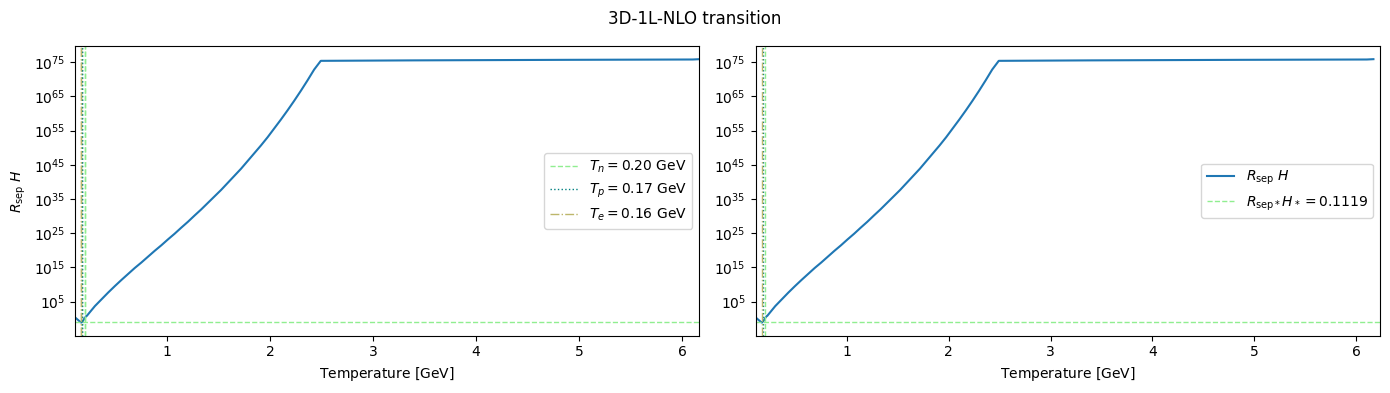

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, RH) #, label = '$R H$')
axes[0].set_ylabel('$R_\mathrm{sep}\ H$')
axes[0].set_yscale('log')
axes[0].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1) #, label=f'$R_* H_* = {RH_interp:.4f}$')
axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
axes[0].set_xlim(Temps[0], Temps[np.max(np.where(RH < np.inf)[0])])
axes[0].legend()

axes[1].plot(Temps[mask], RH[mask], label = '$R_\mathrm{sep}\ H$')
#axes[1].set_ylabel('$R\ H$')
axes[1].set_yscale('log')
axes[1].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1, label=f'$R_\mathrm{{sep *}} H_* = {RH_interp:.4f}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])
axes[1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2e} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2e} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2e} {units}')
    ax.set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")

# handles, labels = axes[1].get_legend_handles_labels()
# axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

#fig.suptitle(f'Mean bubble separation - {description}')
fig.suptitle(f'{description} transition', y=0.97)
plt.savefig(figure_dir + f"RH_{description}.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

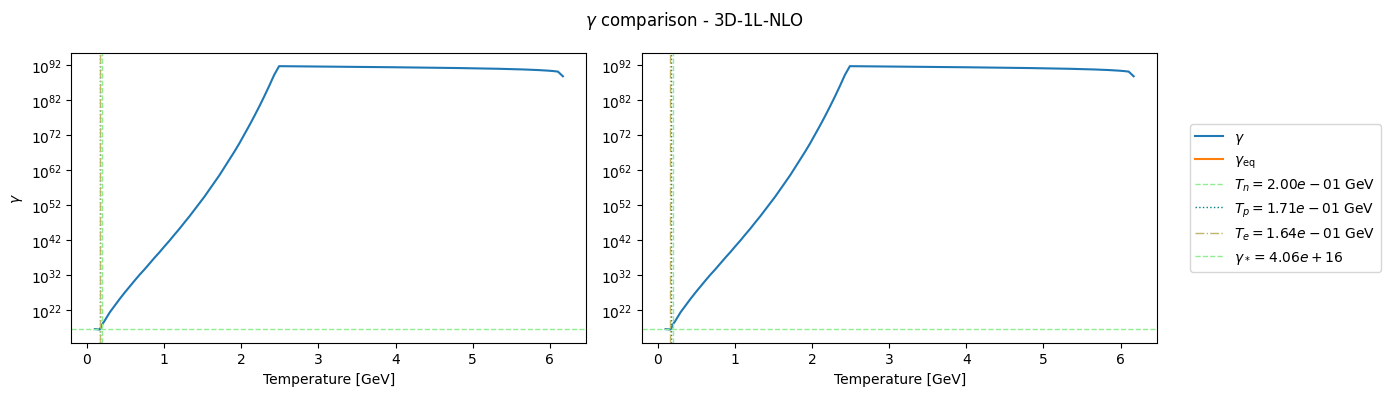

In [35]:
from utils import interpolation_narrow
import numpy as np
import matplotlib.pyplot as plt

def scalar(x):
    return float(np.asarray(x, dtype=float).reshape(-1)[0])


def dict_interp(d, T):
    T = float(T)
    keys = np.asarray(sorted(d.keys()), dtype=float)
    vals = np.asarray([scalar(d[k]) for k in keys], dtype=float)

    if T <= keys[0]:
        return vals[0]
    if T >= keys[-1]:
        return vals[-1]

    return float(np.interp(T, keys, vals))


def R0_safe(T, S3_T, V_exit):
    T = float(T)

    S3_over_T_val = dict_interp(S3_T, T)
    V_exit_val = dict_interp(V_exit, T)

    E0V = S3_over_T_val * T
    DV = -V_exit_val

    if DV <= 0 or not np.isfinite(DV):
        return np.nan

    return (3.0 * E0V / (4.0 * np.pi * DV))**(1.0 / 3.0)

r0 = np.array([
    R0_safe(float(T), S3overT, V_exit)
    for T in Temps
], dtype=float)

gamma_eq_T = (alpha_T - alpha_inf_T) / alpha_eq_T

R = np.asarray(R, dtype=float)
gamma = 2.0 * R / (3.0 * r0)

R_star = scalar(interpolation_narrow(Temps, R, T_perc))
r0_star = R0_safe(float(T_perc), S3overT, V_exit)

gamma_star = 2.0 * R_star / (3.0 * r0_star)
gamma_eq_star = scalar(interpolation_narrow(Temps, gamma_eq_T, T_perc))

mask = np.asarray(mask, dtype=bool)
if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, gamma, label=r'$\gamma$')
axes[0].plot(Temps, gamma_eq_T, label=r'$\gamma_{\mathrm{eq}}$')
axes[0].set_yscale('log')
axes[0].set_xlabel(f'Temperature [{units}]')
axes[0].set_ylabel(r'$\gamma$')

axes[1].plot(Temps[mask], gamma[mask], label=r'$\gamma$')
axes[1].plot(Temps[mask], gamma_eq_T[mask], label=r'$\gamma_{\mathrm{eq}}$')
axes[1].set_yscale('log')
axes[1].set_xlabel(f'Temperature [{units}]')

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$T_n = {T_nuc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=fr'$T_p = {T_perc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=fr'$T_e = {T_completion:.2e}\ \mathrm{{{units}}}$')

    if np.isfinite(gamma_star):
        ax.axhline(gamma_star, color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$\gamma_* = {gamma_star:.2e}$')
    if np.isfinite(gamma_eq_star):
        ax.axhline(gamma_eq_star, color='lightgreen', linestyle=':', linewidth=1,
                   label=fr'$\gamma_{{\mathrm{{eq}},*}} = {gamma_eq_star:.2e}$')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(fr'$\gamma$ comparison - {description}')
plt.tight_layout()
plt.show()

In [37]:
import numpy as np
from scipy.interpolate import UnivariateSpline

def compute_beta_over_H(T_arr, S3T_arr, Tn, window_frac=0.08, k=3):
    T_arr = np.asarray(T_arr, dtype=float)
    S3T_arr = np.asarray(S3T_arr, dtype=float)
    Tn = float(Tn)

    mask = np.isfinite(T_arr) & np.isfinite(S3T_arr)
    T_arr = T_arr[mask]
    S3T_arr = S3T_arr[mask]

    idx = np.argsort(T_arr)
    T_arr = T_arr[idx]
    S3T_arr = S3T_arr[idx]

    # use local points around Tn
    mask_local = np.abs(T_arr - Tn) <= window_frac * Tn

    if np.sum(mask_local) < 5:
        # fallback: use nearest 7 points
        nearest = np.argsort(np.abs(T_arr - Tn))[:7]
        mask_local = np.zeros_like(T_arr, dtype=bool)
        mask_local[nearest] = True

    T_local = T_arr[mask_local]
    S_local = S3T_arr[mask_local]

    idx = np.argsort(T_local)
    T_local = T_local[idx]
    S_local = S_local[idx]

    k = min(k, len(T_local) - 1)

    spline = UnivariateSpline(T_local, S_local, k=k, s=0)
    dS_dT = float(spline.derivative()(Tn))

    beta_H = Tn * dS_dT

    return beta_H

In [40]:
beta_over_H = compute_beta_over_H(valid_T, valid_S3, T_nuc)

print("beta/H =", beta_over_H)

beta/H = 65.55382619309744
